In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings
warnings.filterwarnings('ignore')
from folium.plugins import FastMarkerCluster
from sklearn.pipeline import Pipeline
from sklearn import preprocessing,  metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score



In [79]:
#mengimpor kumpulan data pada home_data csv
data = pd.read_csv('home_data.csv')
data.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [80]:
#menghapus kolom yang tidak di butuhkan seperti id,date,zip,lat dan longdata.drop
data.drop(['id','date'], axis=1, inplace=True)

In [81]:
#describe untuk mengetahui harga rata rata rumah,  maximum maupun minumum dan juga rata rata kamar tidur
data.info()  # melihat tipe data setiap kolom
data.describe()  # statistik: min, max, mean, std setiap kolom

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  int64  
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  float64
 17  sqft_living15  21613 non-null  int64  
 18  sqft_lot15     21

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [82]:
#jika hasilnya tidak ada 0 maka data sudah bersih tidak ada yang kosong
data.isnull().sum() # cek nilai kosong (missing values)
data.nunique()    # hitung nilai unik per kolom

price            4032
bedrooms           13
bathrooms          30
sqft_living      1038
sqft_lot         9782
floors              6
waterfront          2
view                5
condition           5
grade              12
sqft_above        946
sqft_basement     306
yr_built          116
yr_renovated       70
zipcode            70
lat              5034
long              752
sqft_living15     777
sqft_lot15       8689
dtype: int64

In [83]:
#ubah tipe data 
data['bathrooms'] = data['bathrooms'].astype(int)
data['floors'] = data['floors'].astype(int)

#ubah yr_built menjadi "umur rumah "
data.rename(columns={'yr_built': 'age'}, inplace=True) 
data['age'] = 2023 - data ['age']

# Ubah yr_renovated menjadi binary (0/1)
data.rename(columns={'yr_renovated': 'renovated'}, inplace=True)  
data['renovated'] = data['renovated'].apply(lambda x: 0 if x == 0 else 1)

In [84]:
data['sqft_living'] = data['sqft_living'] /data['sqft_living'].max()
data['sqft_lot'] = data['sqft_lot'] /data['sqft_lot'].max()
data['sqft_above'] = data['sqft_above'] /data['sqft_above'].max()
data['sqft_basement'] = data['sqft_basement'] /data['sqft_basement'].max()
data['sqft_living15'] = data['sqft_living15'] /data['sqft_living15'].max()
data['sqft_lot15'] = data['sqft_lot15'] /data['sqft_lot15'].max()

#Semua kolom luas (sqft) dibagi nilai maksimumnya sehingga nilainya menjadi 0 sampai 1.
# Ini disebut Min-Max Scaling manual. Tujuannya agar model tidak bias terhadap kolom dengan angka besar.

<Axes: >

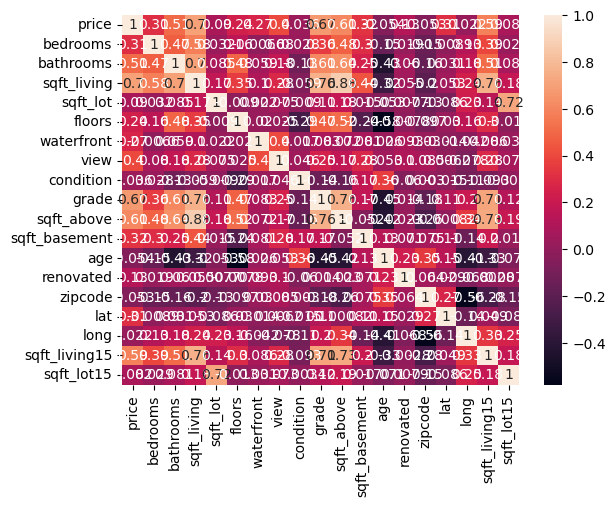

In [85]:
#korelasi EDA
data.corr()['price'].sort_values(ascending=False) #korelasi harga
sns.heatmap(data.corr(), annot=True) #heatmap korelasi

#menghitung seberapa kuat hubungan antar fitur dengan harga (price)
#fitur dengan korelasi tertinggi terhadap harga adalah (sqft_living,grade,sqft_above dan bathrooms)

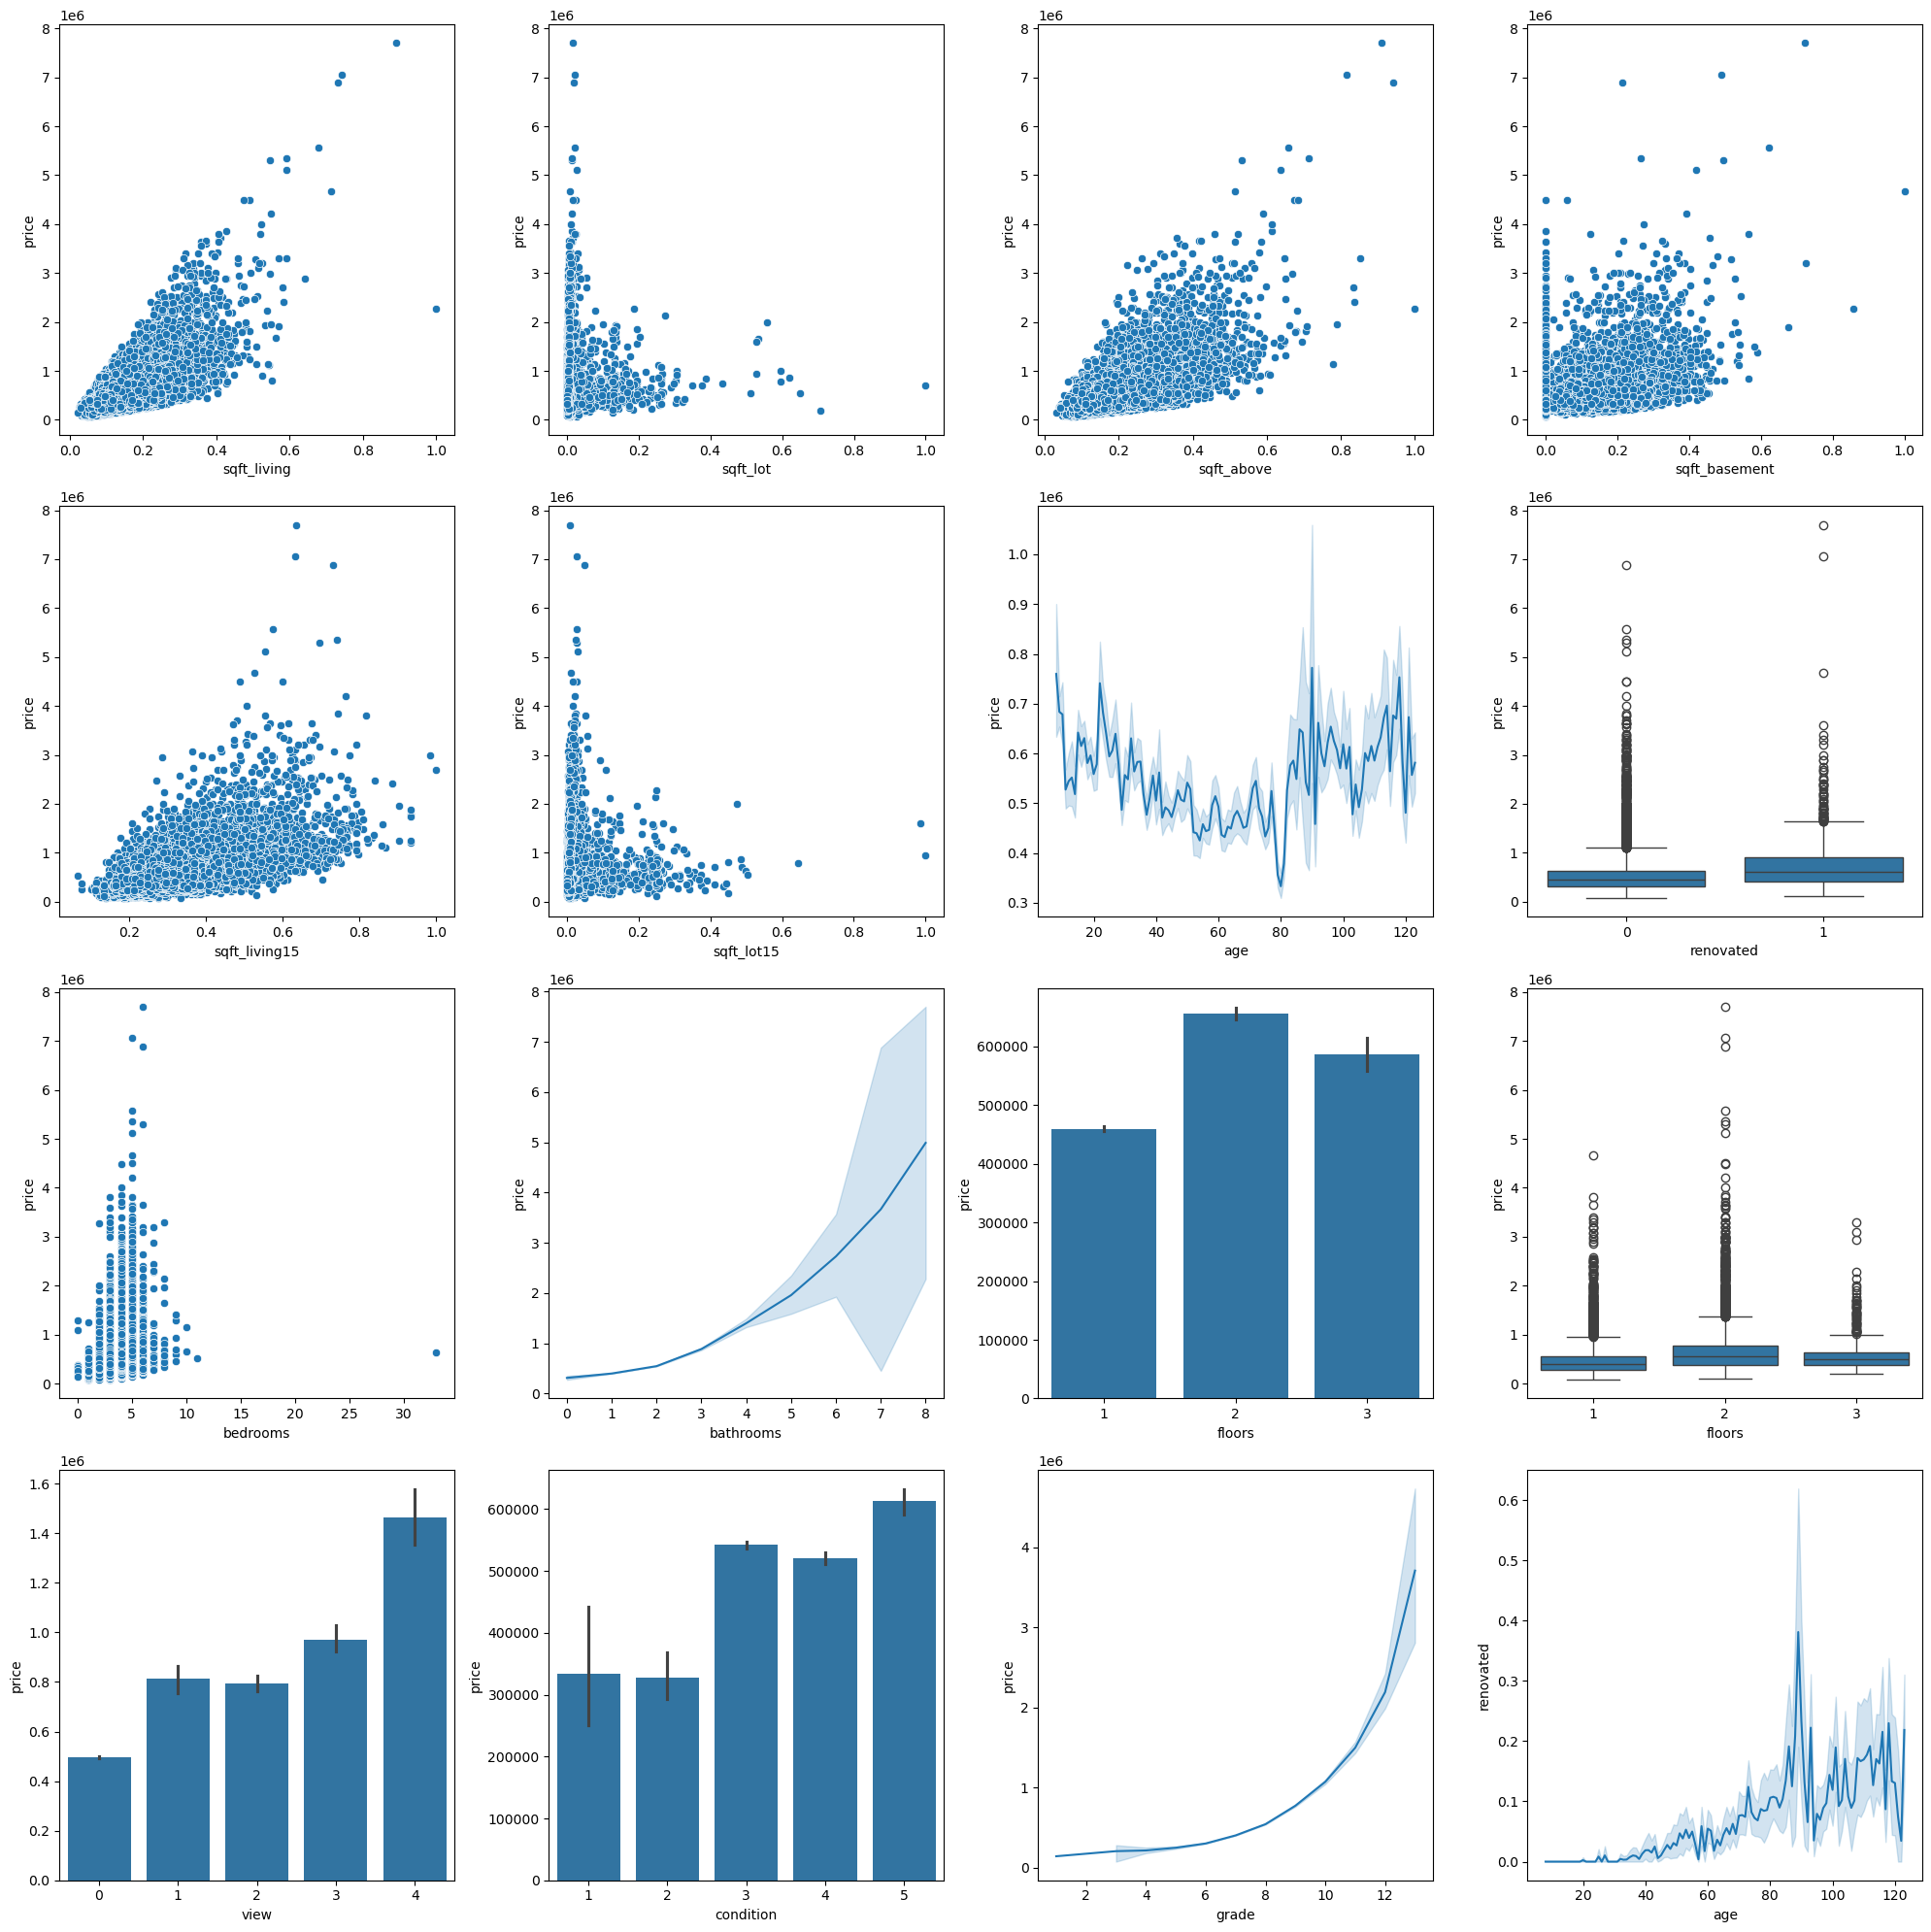

In [86]:
fig, ax = plt.subplots(4,4, figsize=(20,20))
#baris 1
sns.scatterplot(x=data ['sqft_living'],y=data['price'], ax=ax[0,0])
sns.scatterplot(x=data ['sqft_lot'], y=data['price'], ax=ax[0,1])
sns.scatterplot(x=data ['sqft_above'], y=data['price'], ax=ax[0,2])
sns.scatterplot(x=data ['sqft_basement'], y=data['price'], ax=ax[0,3])
#baris 2
sns.scatterplot(x=data ['sqft_living15'], y=data['price'], ax=ax[1,0])
sns.scatterplot(x=data ['sqft_lot15'], y=data['price'], ax=ax[1,1])
sns.lineplot(x=data ['age'], y=data['price'], ax=ax[1,2]) 
sns.boxplot(x=data ['renovated'], y=data['price'], ax=ax[1,3])

#baris 3
sns.scatterplot(x=data ['bedrooms'], y=data['price'], ax=ax[2,0])
sns.lineplot(x=data ['bathrooms'], y=data['price'], ax=ax[2,1])
sns.barplot(x=data ['floors'], y=data['price'], ax=ax[2,2])
sns.boxplot(x=data ['floors'], y=data['price'], ax=ax[2,3])

#baris 4
sns.barplot(x=data ['view'], y=data['price'], ax=ax[3,0])
sns.barplot(x=data ['condition'], y=data['price'], ax=ax[3,1])
sns.lineplot(x=data ['grade'], y=data['price'], ax=ax[3,2])
sns.lineplot(x=data ['age'], y=data['renovated'], ax=ax[3,3])

plt.tight_layout()
plt.show()

#Membuat grid 4x4 grafik untuk melihat hubungan setiap fitur dengan harga secara visual. 
# Jenis grafik yang digunakan: scatterplot, lineplot, barplot, dan boxplot sesuai jenis datanya.

In [87]:
data['price_range'] = pd.cut(data['price'],
    bins=[0, 321950, 450000, 645000, 1295648],
    labels=['low', 'medium', 'high', 'very high'])

map = folium.Map(location=[47.5480, -121.9836], zoom_start=8)
FastMarkerCluster(data[['lat', 'long']].values.tolist()).add_to(map)

#Harga dikategorikan menjadi 4 level (Low/Medium/High/Very High), lalu semua lokasi rumah diplot ke peta interaktif berdasarkan koordinat latitude dan longitude. 
# Ini membuktikan bahwa lokasi sangat mempengaruhi harga.

In [88]:
data.drop(['price_range'], axis=1, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    data.drop('price', axis=1),  # X = semua kolom kecuali price
    data['price'],               # y = price (target)
    test_size=0.3,               # 30% untuk testing
    random_state=10              # agar hasil bisa direproduksi
)
#Data dibagi: 70% untuk melatih model, 30% untuk menguji model.

In [122]:
input = [
    ('scale', StandardScaler()),           # normalisasi data
    ('polynomial', PolynomialFeatures(degree=2)),  # buat fitur kuadrat
    ('model', LinearRegression())          # latih regresi linear
]
pipe = Pipeline(input)
pipe.fit(X_train, y_train)
pipe_pred = pipe.predict(X_test)
r2_score(y_test, pipe_pred)

#Pipeline menggabungkan 3 langkah otomatis:
#StandardScaler → standarisasi data (mean=0, std=1)
#PolynomialFeatures(degree=2) → membuat fitur baru seperti X², X₁×X₂ agar model menangkap hubungan non-linear
#LinearRegression → melatih model regresi

0.8271766840410678

In [ ]:
from sklearn.metrics import r2_score  
RidgeModel = Ridge(alpha=0.001)
RidgeModel.fit(X_train, y_train)
r_pred = RidgeModel.predict(X_test)   # ← X_train jadi X_test
r2_score(y_test, r_pred)             
#Ridge Regression adalah regresi linear biasa tapi dengan penalti (regularisasi) untuk mencegah overfitting.
#Parameter alpha=0.001 mengontrol seberapa besar penaltinya — semakin kecil alpha, semakin mirip dengan linear regression biasa.

0.7123220593275169

In [128]:
from sklearn.metrics import r2_score

regressor = RandomForestRegressor(n_estimators=100, random_state=0)
regressor.fit(X_train, y_train)
yhat = regressor.predict(X_test)      # ← pipe_pred jadi yhat
rf_r2 = r2_score(y_test, yhat)
print("Random Forest R2 Score:", rf_r2)

Random Forest R2 Score: 0.878968081057204


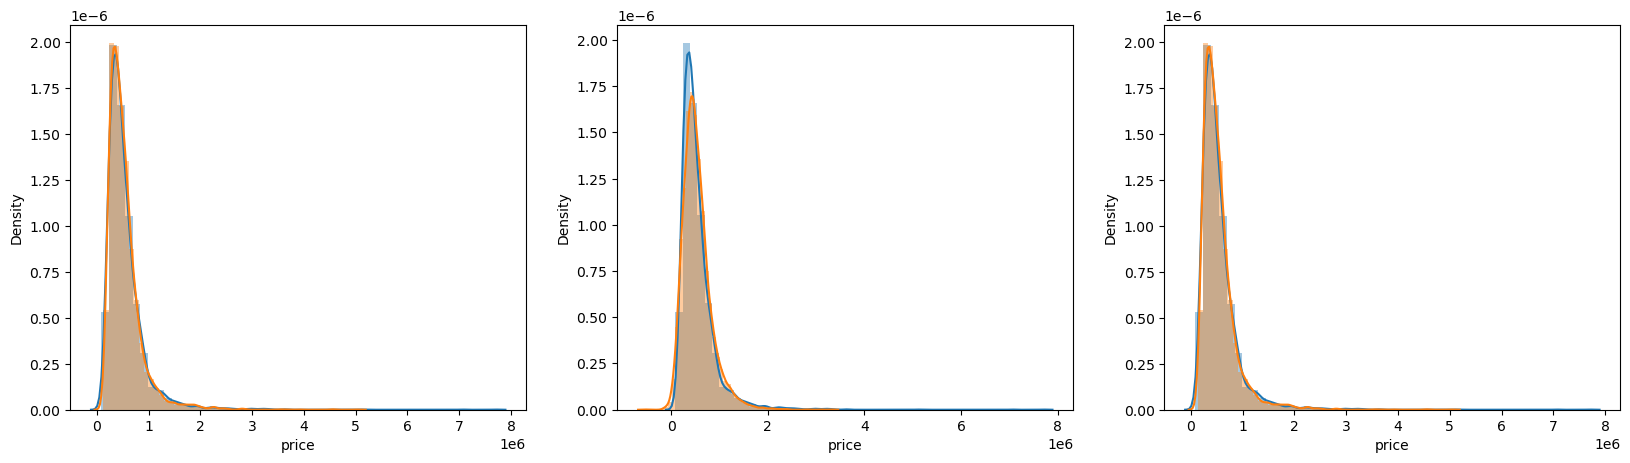

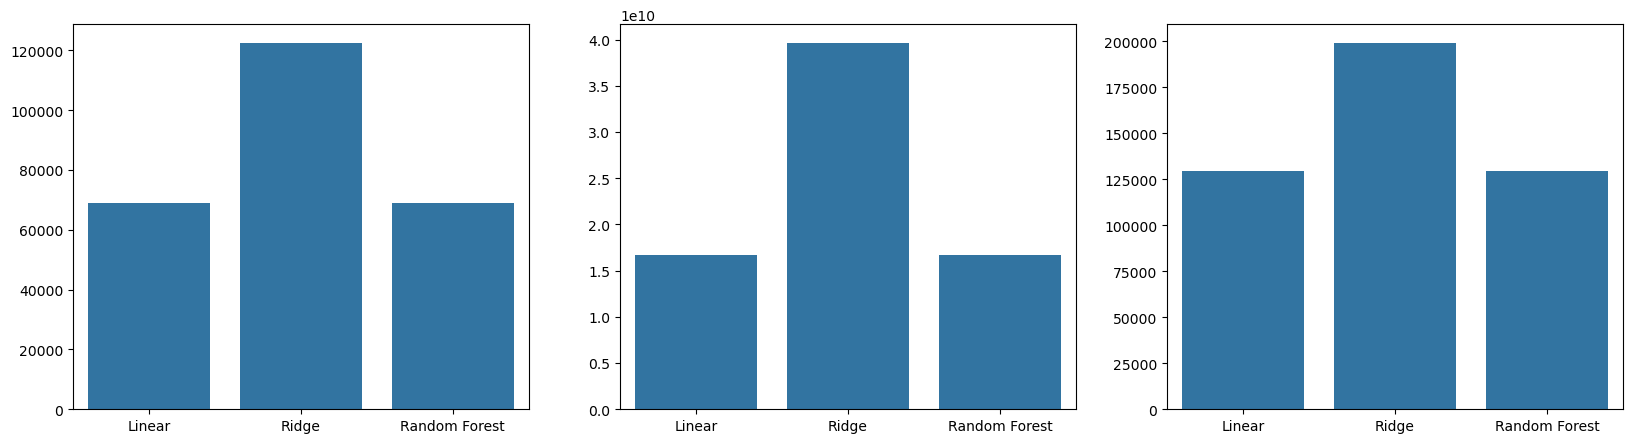

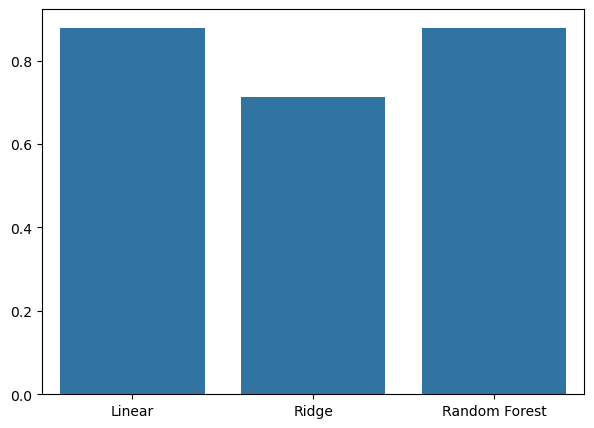

In [ ]:
# Distribusi prediksi vs aktual
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
sns.distplot(y_test, ax=ax[0]); sns.distplot(pipe_pred, ax=ax[0])
sns.distplot(y_test, ax=ax[1]); sns.distplot(r_pred, ax=ax[1])
sns.distplot(y_test, ax=ax[2]); sns.distplot(yhat, ax=ax[2])
plt.show()

# Perbandingan error
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(x=['Linear','Ridge','Random Forest'], y=[mean_absolute_error(y_test,pipe_pred), mean_absolute_error(y_test,r_pred), mean_absolute_error(y_test,yhat)], ax=ax[0]) #Linear Regression
sns.barplot(x=['Linear','Ridge','Random Forest'], y=[mean_squared_error(y_test,pipe_pred), mean_squared_error(y_test,r_pred), mean_squared_error(y_test,yhat)], ax=ax[1]) #ridge regression
sns.barplot(x=['Linear','Ridge','Random Forest'], y=[np.sqrt(mean_squared_error(y_test,pipe_pred)), np.sqrt(mean_squared_error(y_test,r_pred)), np.sqrt(mean_squared_error(y_test,yhat))], ax=ax[2]) #random forest
plt.show()

# Perbandingan akurasi R²
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=['Linear','Ridge','Random Forest'], y=[r2_score(y_test,pipe_pred), r2_score(y_test,r_pred), r2_score(y_test,yhat)])
plt.show()

In [131]:
# Input fitur rumah baru yang ingin diprediksi
bedrooms = 3
bathrooms = 2
sqft_living = 2000
sqft_lot = 10000
floors = 2
waterfront = 0
view = 0
condition = 3
grade = 8
sqft_above = 2000
sqft_basement = 0
yr_built = 1990
yr_renovated = 0
zipcode = 98001
lat = 47.5480
long = -121.9836
sqft_living15 = 2000
sqft_lot15 = 10000

# Prediksi harga menggunakan Random Forest (model terbaik)
price = regressor.predict([[bedrooms, bathrooms, sqft_living, sqft_lot, floors,
                            waterfront, view, condition, grade, sqft_above,
                            sqft_basement, yr_built, yr_renovated, zipcode,
                            lat, long, sqft_living15, sqft_lot15]])

# Tampilkan hasil prediksi harga rumah
print('The price of the house is $', f'{price[0]:,.2f}')

The price of the house is $ 1,078,694.05
